import the code libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

### read in the dataset and describe its shape, data types, stats, valid categorical values, domain and provenance ###

In [2]:
co2_data = pd.read_csv('personal_carbon_footprint_behavior_raw.csv')
co2_df = pd.DataFrame(co2_data)
print(co2_data.shape)
co2_df.info()

(1400, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              1400 non-null   int64  
 1   day_type             1400 non-null   object 
 2   transport_mode       1400 non-null   object 
 3   distance_km          1400 non-null   float64
 4   electricity_kwh      1400 non-null   float64
 5   renewable_usage_pct  1400 non-null   int64  
 6   food_type            1400 non-null   object 
 7   screen_time_hours    1400 non-null   float64
 8   waste_generated_kg   1400 non-null   float64
 9   eco_actions          1400 non-null   int64  
 10  carbon_footprint_kg  1400 non-null   float64
 11  carbon_impact_level  1400 non-null   object 
dtypes: float64(5), int64(3), object(4)
memory usage: 131.4+ KB


In [3]:
print(co2_df['day_type'].unique())
print(co2_df['transport_mode'].unique())
print(co2_df['food_type'].unique())
print(co2_df['carbon_impact_level'].unique())

['Weekend' 'Weekday']
['EV' 'Walk' 'Bike' 'Bus' 'Car']
['Non-Veg' 'Mixed' 'Veg']
['High' 'Medium' 'Low']


In [4]:
co2_df.describe()

,user_id,distance_km,electricity_kwh,renewable_usage_pct,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg
count,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000
mean,100.500000,9.106071,5.951443,31.589286,5.521786,0.703200,1.144286,7.980236
std,57.754936,4.734692,1.993266,30.598496,2.018918,0.236415,1.019066,2.657858
min,1.000000,0.500000,2.000000,0.000000,2.000000,0.100000,0.000000,1.790000
25%,50.750000,5.662500,4.530000,0.000000,3.800000,0.550000,0.000000,6.080000
50%,100.500000,9.180000,5.925000,25.000000,5.550000,0.705000,1.000000,7.835000
75%,150.250000,12.510000,7.290000,50.000000,7.300000,0.860000,2.000000,9.830000
max,200.000000,22.670000,12.270000,100.000000,9.000000,1.510000,5.000000,16.020000


Personal Carbon Footprint Behaviour dataset. From Kaggle, Sonal Shinde

This dataset captures daily lifestyle behaviors and sustainability-related actions of individuals and their resulting carbon footprint impact.

It combines transport choices, energy usage, food habits, digital behavior, waste generation, and eco-friendly actions to estimate a person’s carbon footprint (kg CO₂ equivalent) and classify their carbon impact level as Low, Medium, or High.

Each record represents one day of activity for a specific user.


There are 200 subjects, each with 7 days of 9 observations and 2 results per day: Co2 kgs and a categorical level: H, M, L

Of the 9 observations:
 - 3 are categorical
 - 2 are numeric but with discrete (non continuous) values
 - 4 are numeric, continuous values
The 6 numerical values are mentioned in the description as being combined to generate the two target variables.

### any problems with the data: missing values, outliers, correlation ###

In [19]:
# missing data
co2_df.isnull().sum()

user_id                0
day_type               0
transport_mode         0
distance_km            0
electricity_kwh        0
renewable_usage_pct    0
food_type              0
screen_time_hours      0
waste_generated_kg     0
eco_actions            0
carbon_footprint_kg    0
carbon_impact_level    0
dtype: int64

<Figure size 640x480 with 0 Axes>

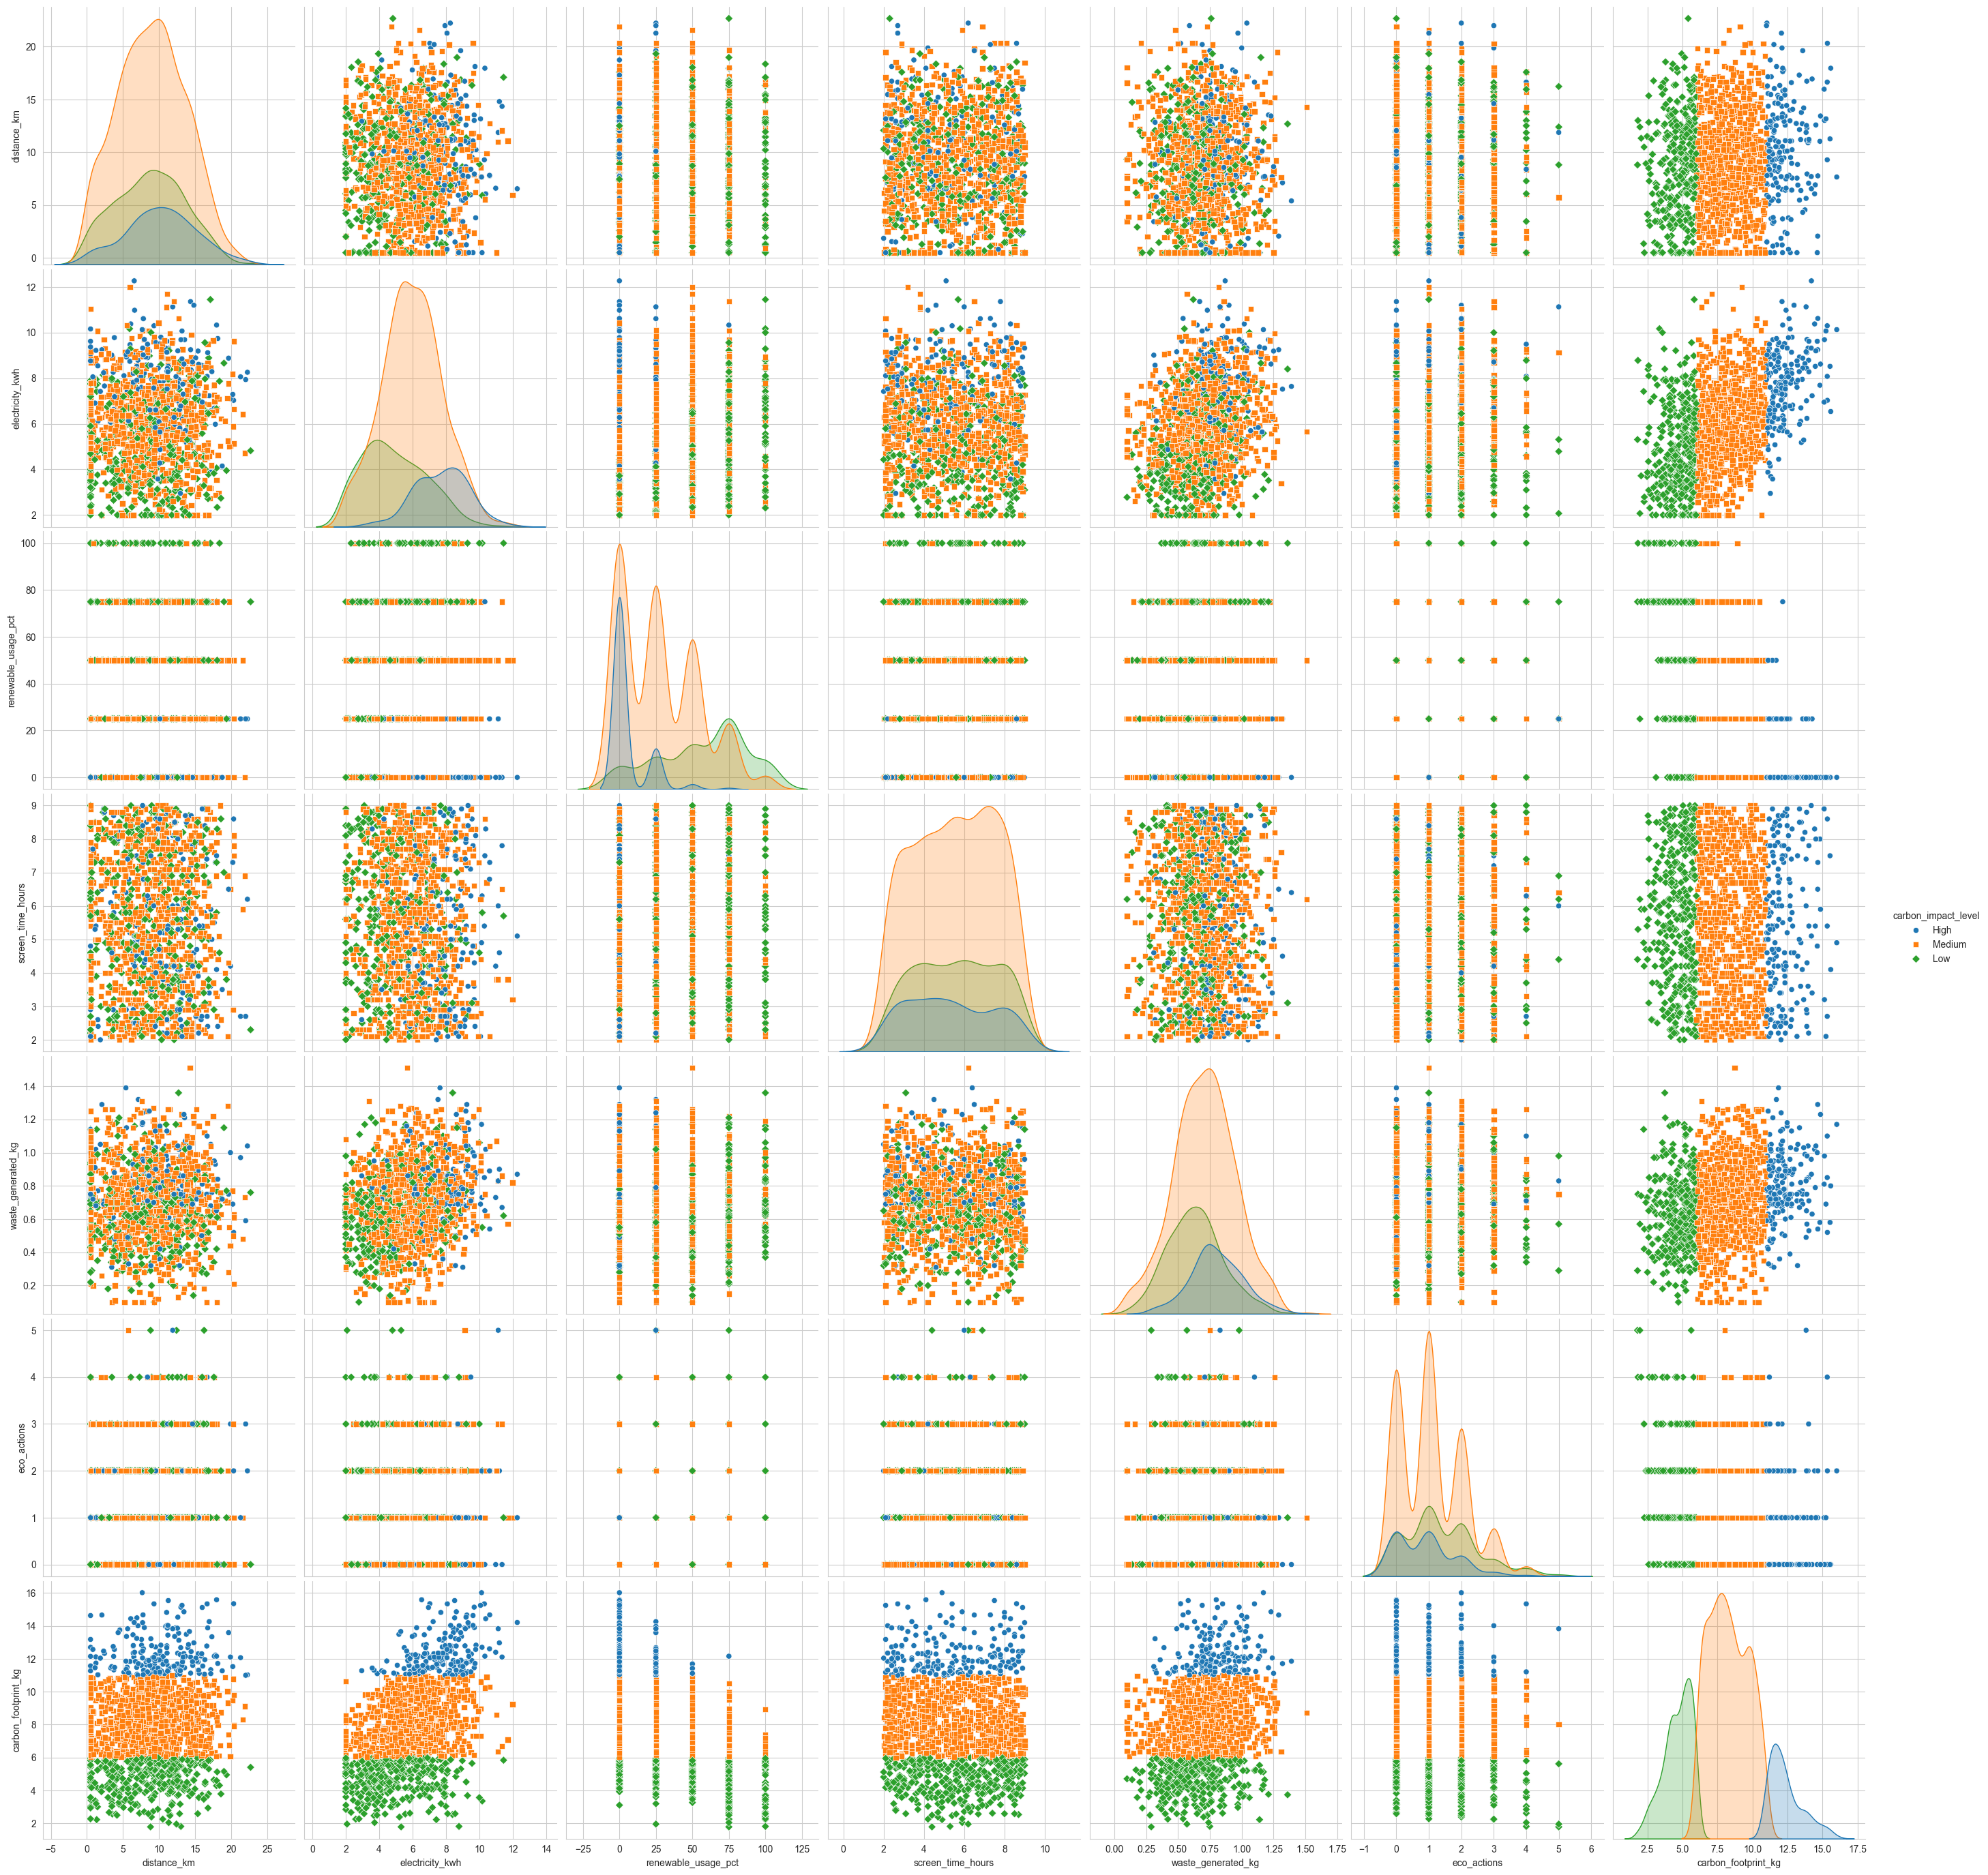

In [6]:
# visualisations for correlation, distribution and outliers

sns.set_style('whitegrid')
select_cols1 = ['distance_km', 'electricity_kwh', 'renewable_usage_pct', 'screen_time_hours', 'waste_generated_kg', 'eco_actions', 'carbon_footprint_kg']
plt.figure()
sns.pairplot(co2_df,vars=select_cols1,hue = 'carbon_impact_level', height=4, markers=['o','s','D'])
plt.show()

<Figure size 640x480 with 0 Axes>

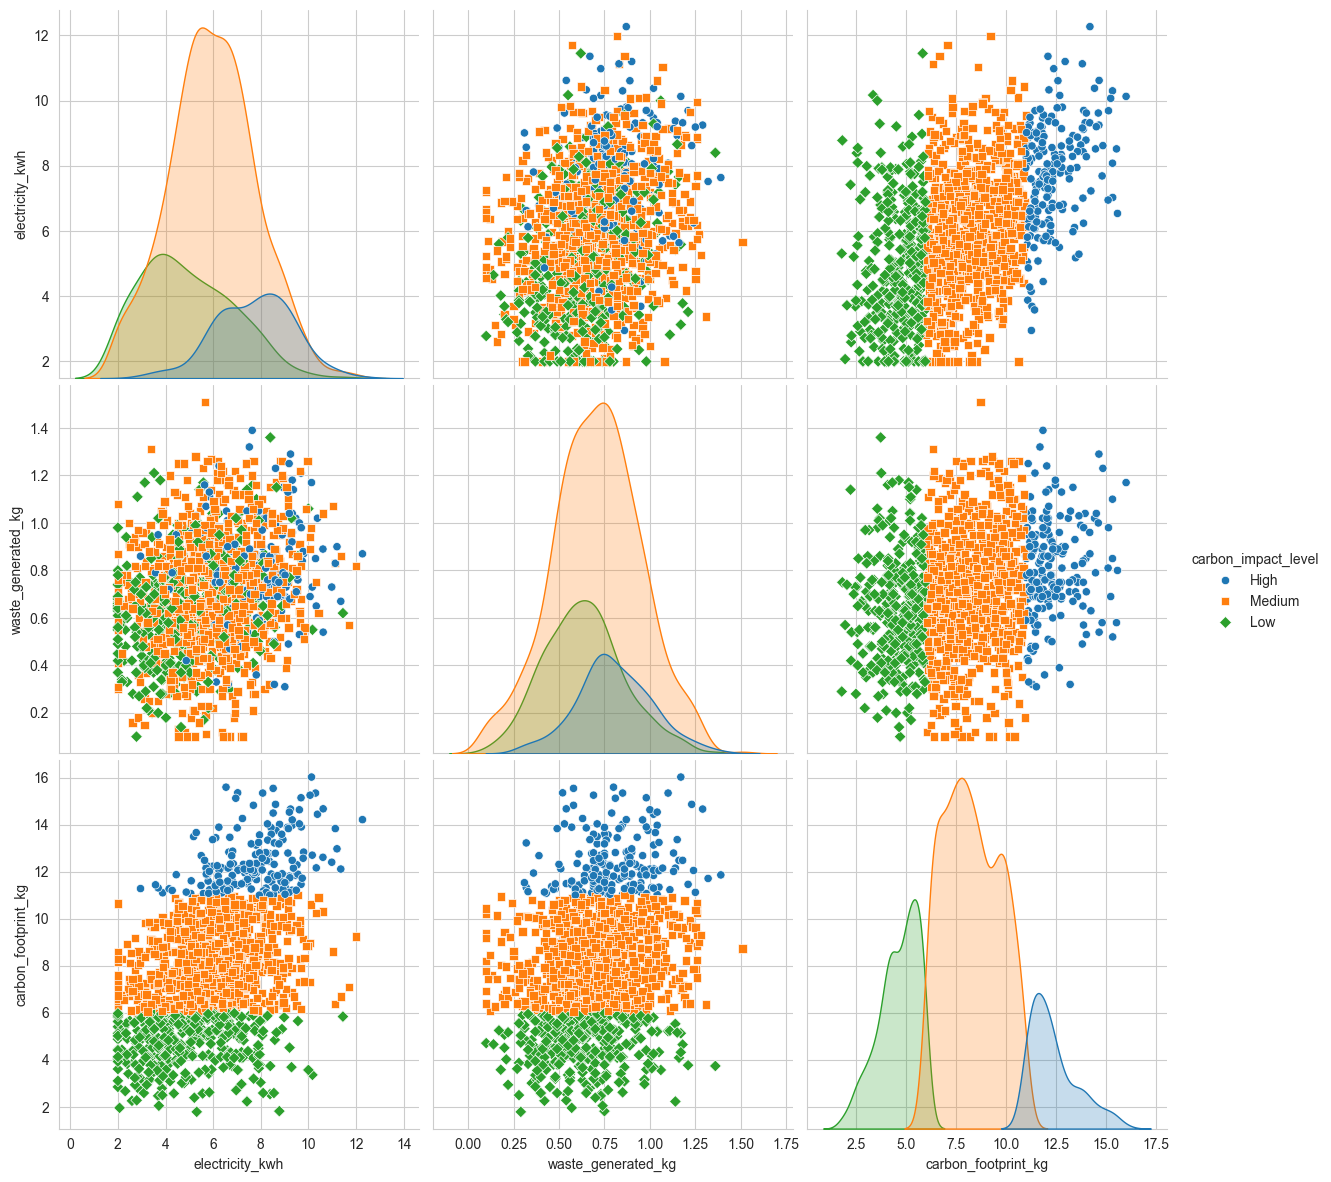

In [7]:
# sns.pairplot(co2_df[['electricity_kwh', 'waste_generated_kg', 'carbon_footprint_kg']])
select_cols2=['electricity_kwh', 'waste_generated_kg', 'carbon_footprint_kg']
plt.figure()
sns.pairplot(co2_df,vars=select_cols2,hue = 'carbon_impact_level', height=4, markers=['o','s','D'])
plt.show()

<Figure size 640x480 with 0 Axes>

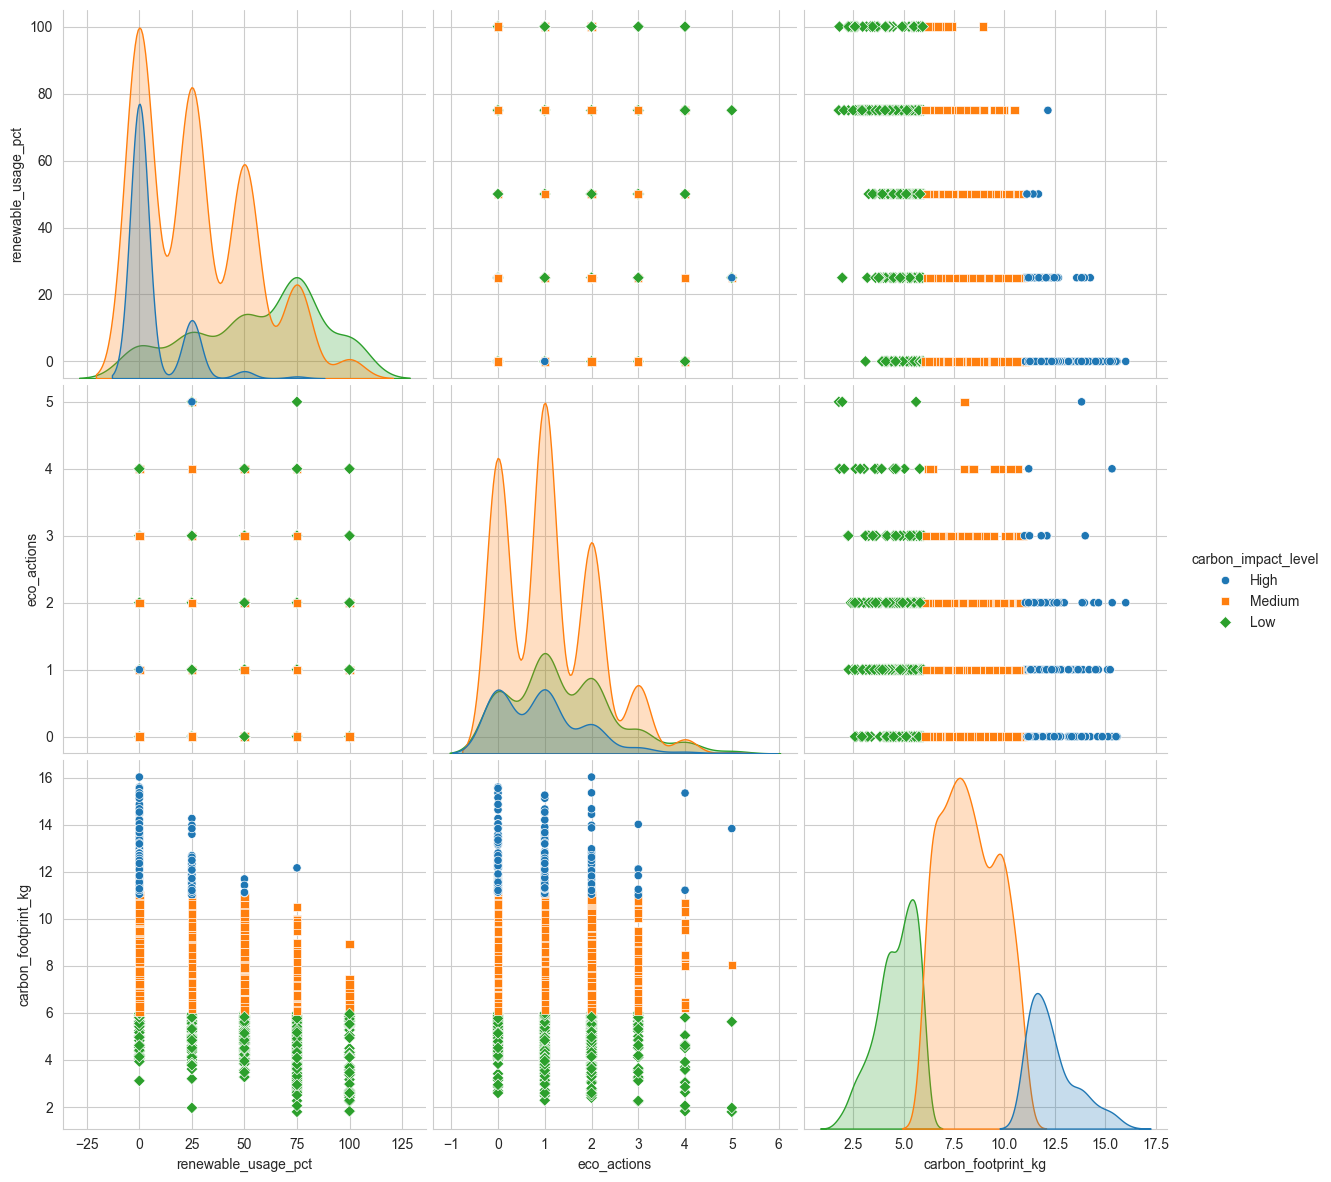

In [8]:

select_cols3=['renewable_usage_pct', 'eco_actions', 'carbon_footprint_kg']
plt.figure()
sns.pairplot(co2_df,vars=select_cols3,hue = 'carbon_impact_level', height=4, markers=['o','s','D'])
plt.show()

In [9]:
print(co2_df['renewable_usage_pct'].unique())
print(co2_df['eco_actions'].unique())

[  0  50  75  25 100]
[1 0 3 4 2 5]


<Axes: >

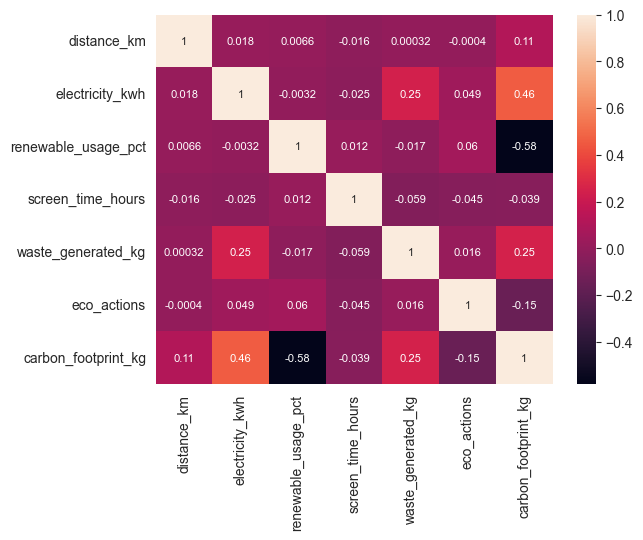

In [18]:
import matplotlib.pyplot as plt
co2_stats = co2_df[['distance_km', 'electricity_kwh', 'renewable_usage_pct', 'screen_time_hours', 'waste_generated_kg', 'eco_actions', 'carbon_footprint_kg']]
corr = co2_stats.corr()
sns.heatmap(corr, annot=True, annot_kws={'size':8})


given these correlation results, wanted to see whether encoding mode of transport would improve the usefulness of the distance travelled feature and whether food type would improve the usefulness of the waste generated variable.

google search: what is the best encoding method for a categorical variable that may be correlated with another continuous variable
Target Encoding (Mean Encoding)
?? for low cardinality values, should I use oneHot?

lmplots used on the positively correlated features (to carbon_footprint_kg), with catergorical features included to provide visualisations that support decsions around encoding.

realise I wold have to decided whether to encode the categorical values based on the continuous or the multiclass target. Decided to try both and include both in the dataset for further processing. This way, can use one version for regression and one for classification.

fig, axes = plt.subplots(2,2,figsize=(12,10))
fig.suptitle('Boxplots for Fruit.csv')

sns.boxplot(data=fruit_dataframe,x='fruit_name',y='mass',ax=axes[0,0])
sns.boxplot(data=fruit_dataframe,x='fruit_name',y='width',ax=axes[0,1])
sns.boxplot(data=fruit_dataframe,x='fruit_name',y='height',ax=axes[1,0])
sns.boxplot(data=fruit_dataframe,x='fruit_name',y='color_score',ax=axes[1,1])
plt.show()

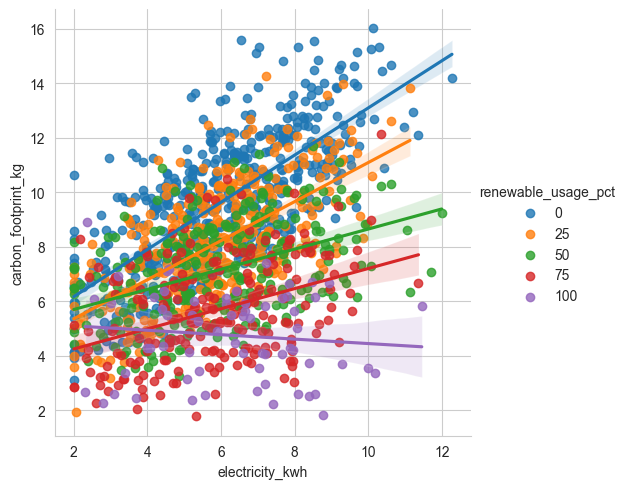

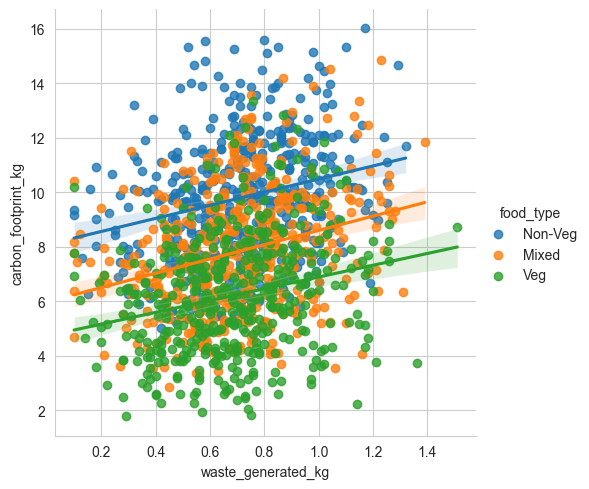

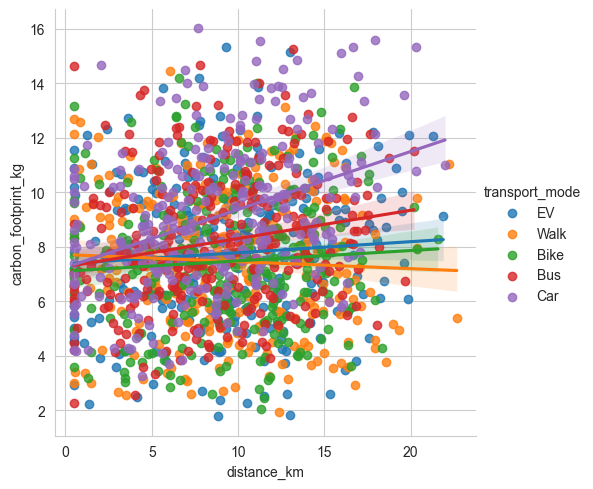

In [11]:

sns.lmplot(x='electricity_kwh', y='carbon_footprint_kg', data = co2_df, hue='renewable_usage_pct')
sns.lmplot(x='waste_generated_kg', y='carbon_footprint_kg', data = co2_df, hue='food_type')
sns.lmplot(x='distance_km', y='carbon_footprint_kg', data = co2_df, hue='transport_mode')



before going further with encoding categorical values, look at outliers

for this next section, need to crack how to use figure & axes, to group together pattern searches.

Pattern search 1: positive correlation
Pattern search 2: outliers
Pattern search 3: negative correlation
Pattern search 4: relationship between targets

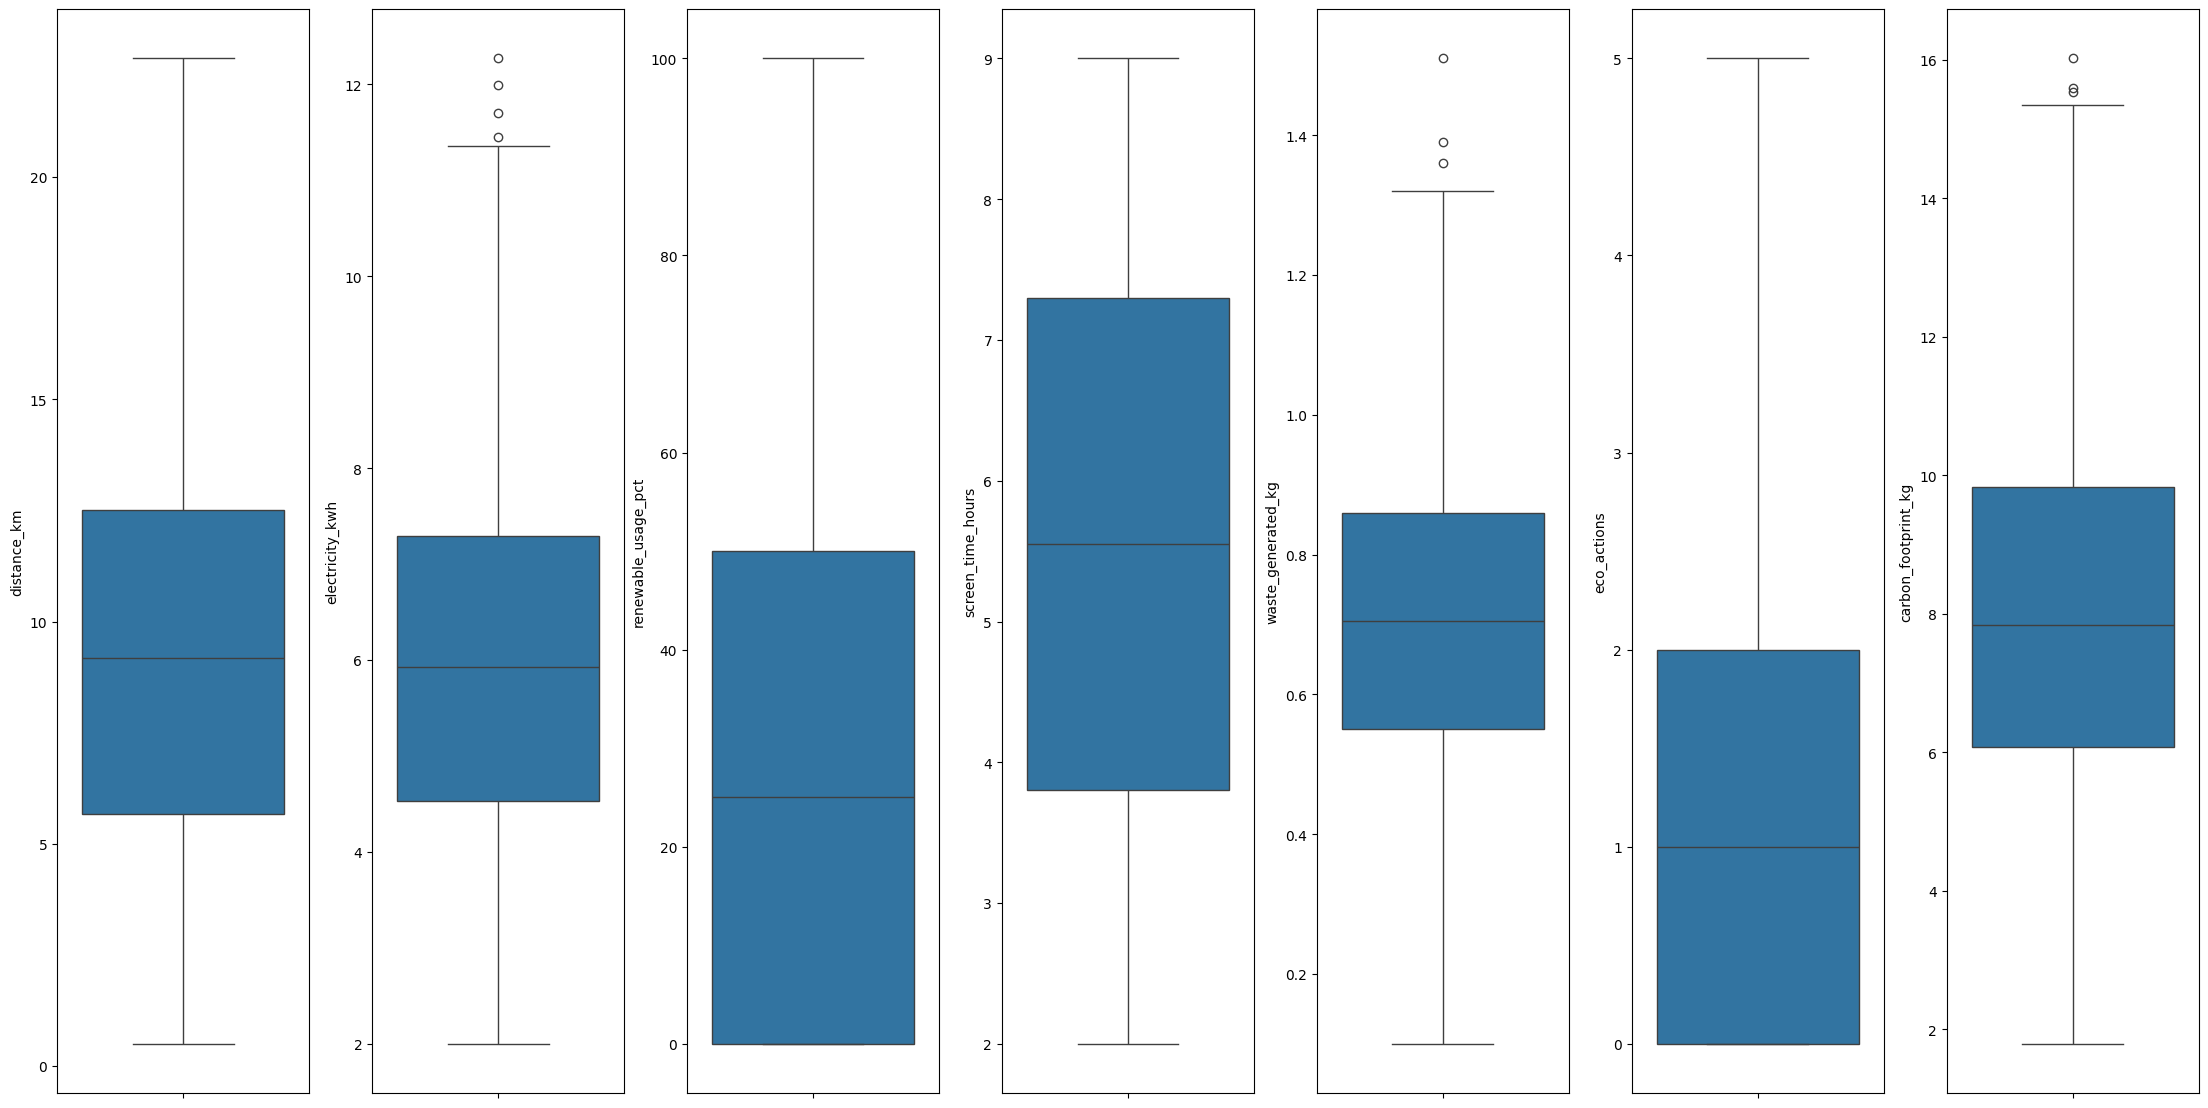

In [ ]:
# this code is copied from one of the sample courseworks - need to go back and understand it and decide whether it's appropriate / to use
# https://matplotlib.org/stable/users/explain/axes/arranging_axes.html
# see also ex 5.1 in week 4 homework

import matplotlib.pyplot as plt
import seaborn as sns
fig, ax=plt.subplots(ncols=7, nrows=1 ,figsize=(22,11))
i=0
ax=ax.flatten()

for col, value in co2_stats.items():
  sns.boxplot(y=col, data=co2_stats , ax=ax[i])
  i=i+1
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)

<Axes: xlabel='electricity_kwh', ylabel='day_type'>

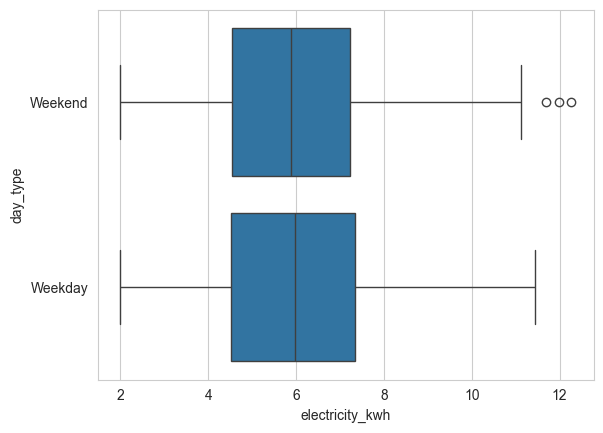

In [13]:

sns.boxplot(co2_df, x='electricity_kwh', y='day_type')

<Axes: xlabel='waste_generated_kg', ylabel='food_type'>

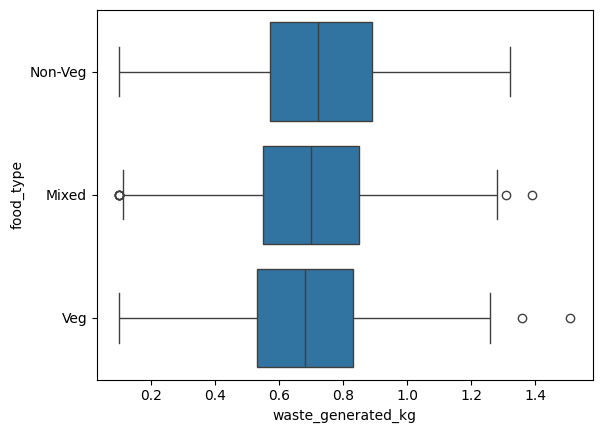

In [50]:
sns.boxplot(co2_df, x='waste_generated_kg', y='food_type')

<Axes: ylabel='waste_generated_kg'>

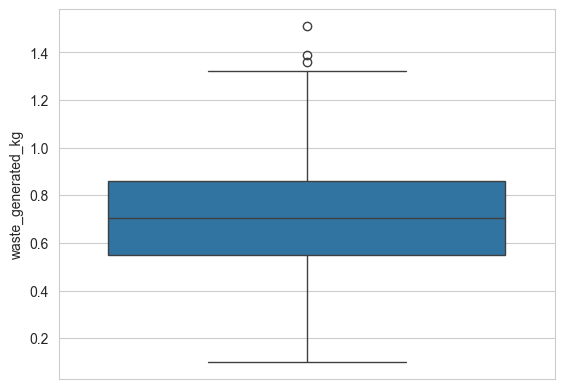

In [99]:
sns.boxplot(co2_df['waste_generated_kg'])

<Axes: xlabel='distance_km', ylabel='transport_mode'>

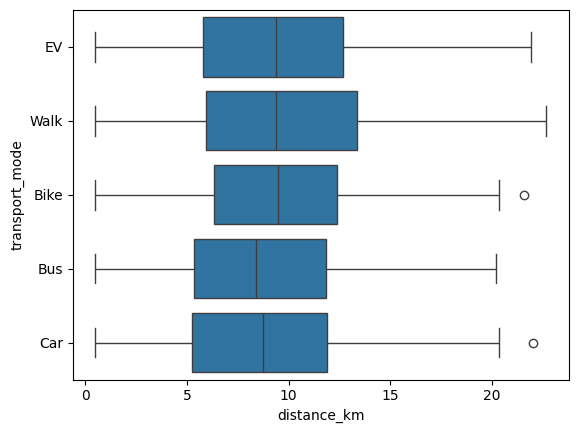

In [ ]:
# Although distance km didn't show outliers, when broken down by mode of transprt, there are some outliers.
sns.boxplot(co2_df, x='distance_km', y='transport_mode')

<Axes: xlabel='distance_km'>

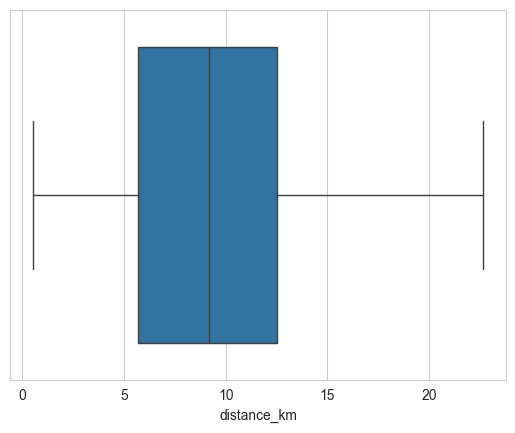

In [102]:
# sns.boxplot(co2_df['distance_km'])
sns.boxplot(co2_df, x='distance_km')

looking at the negative correlations:

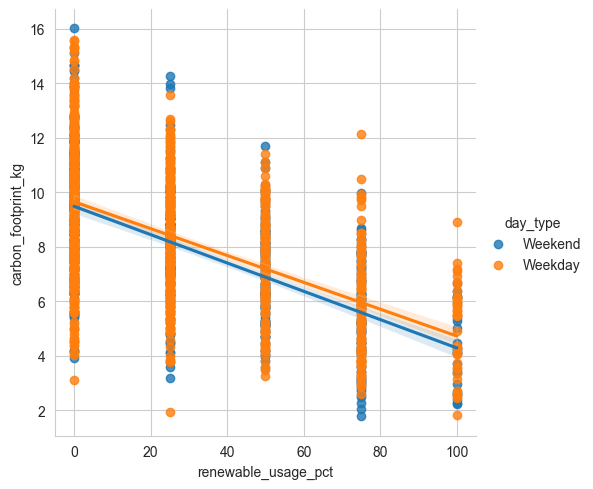

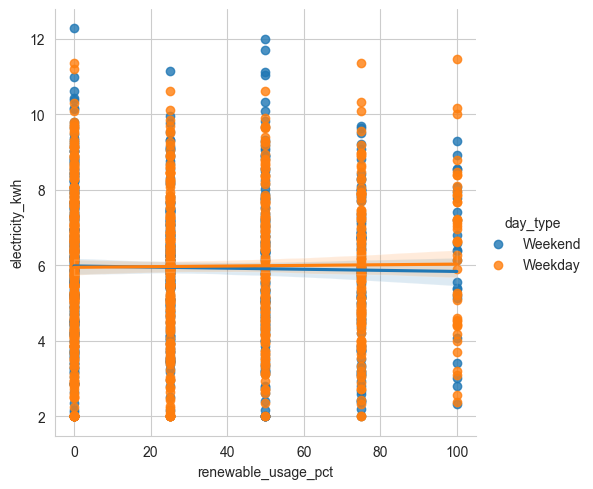

In [14]:
sns.lmplot(x='renewable_usage_pct', y='carbon_footprint_kg', data=co2_df, hue='day_type')
sns.lmplot(x='renewable_usage_pct', y='electricity_kwh', data=co2_df, hue='day_type')

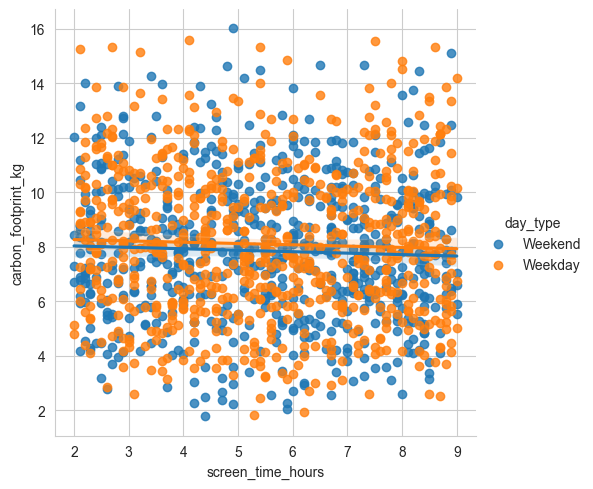

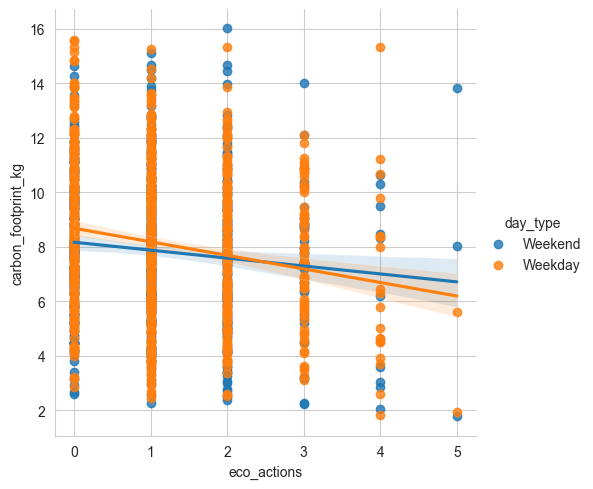

In [15]:
sns.lmplot(x='screen_time_hours', y='carbon_footprint_kg', data=co2_df, hue='day_type')
sns.lmplot(x='eco_actions', y='carbon_footprint_kg', data=co2_df, hue='day_type')

finally, visualise the relationship between the continuous and the categorical targets

The best visualization to see the relationship between a multiclass target variable and the continuous variable(s) on which it is based is a Violin Plot or a set of Side-by-Side Box Plots. (google search)


<Axes: xlabel='carbon_impact_level', ylabel='carbon_footprint_kg'>

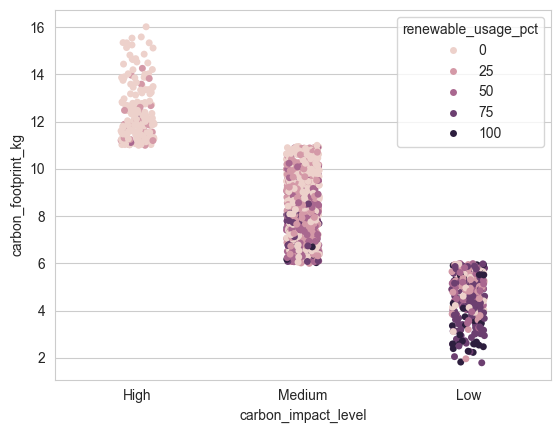

In [65]:
# sns.violinplot(x='carbon_impact_level', y='carbon_footprint_kg', data=co2_df)
sns.set_style('whitegrid')
sns.stripplot(x='carbon_impact_level', y='carbon_footprint_kg', data=co2_df, hue='renewable_usage_pct')

<Axes: xlabel='carbon_impact_level', ylabel='carbon_footprint_kg'>

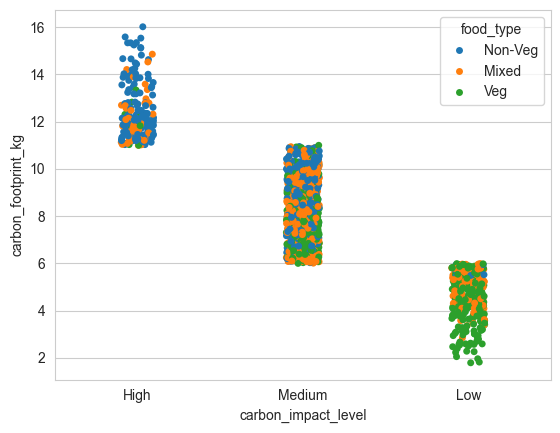

In [ ]:

# generate axes by iterating through the 5 discrete feature values (transport mode, eco actions and day_type don't reveal any patterns to the naked eye)
sns.stripplot(x='carbon_impact_level', y='carbon_footprint_kg', data=co2_df, hue='food_type')

There are two target variables, one continuous and the other multiclass. My goal is to use the same dataset to explore both linear (or polynomial) regression and a classification method.

Today (7th Feb) I have focussed on visualisations around the continuous target 
* need to consider visualisations on the multiclass target * see below. confirms results
* also need to look more closely at the boundary conditions for the multiclass target *

a positive correlation between a feature variable and either of the target variables means that feature variable increases the users carbon footprint as it goes up and visa versa for negative correlation. 


### Pattern type 1: positive correlations ###
the strongest positive correlation is electricity kwh, which does not depend much on day_type, though there are outliers when looked at by day_type. However when looked at by renewable_usage_pct the slope and intercepts vary considerably
there are also positive correlations for distance kms and waste generated. For the latter, when combined with food choices, the slope of the line (ie the amount of correlation to the naked eye does not vary) but food choices and carbon footprint kg appear to be positively correlated. The correlation between distance kms and carbon footprint kg does vary depending on mode of transport

These observations mean it's worth encoding food choices and transport mode, using target encoding

### Pattern type 2: outliers ###
There are some outlier values as shown in the boxplots and these records need to be looked at to determine whether they should be removed

### Pattern type 3: negative correlations ###
the main negative correlation is renewable usage pct, and it's worth noting that the first lmplot provides the most pronounced set of patterns, with a few others then clear but less strong
there is a small amount of negative correlation for eco actions, more so on weekdays and almost none for screen time.




<Axes: xlabel='carbon_impact_level', ylabel='renewable_usage_pct'>

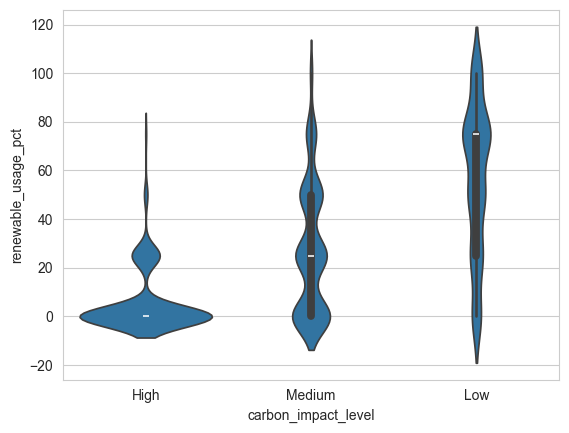

In [ ]:
# need to better be able to express what the violin plots are telling me
sns.violinplot(x='carbon_impact_level', y='renewable_usage_pct', data=co2_df)


<Axes: xlabel='carbon_impact_level', ylabel='electricity_kwh'>

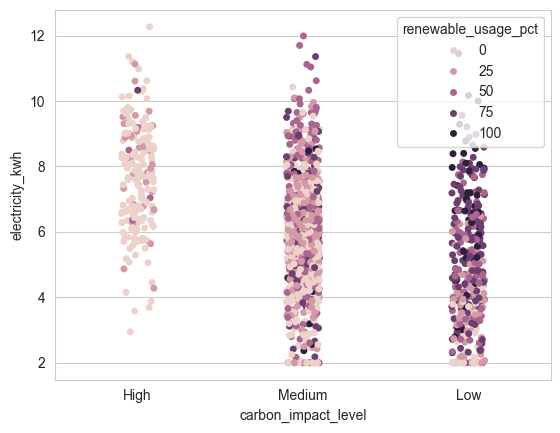

In [86]:
sns.stripplot(x='carbon_impact_level', y='electricity_kwh', data=co2_df, hue='renewable_usage_pct')

<Axes: xlabel='carbon_impact_level', ylabel='waste_generated_kg'>

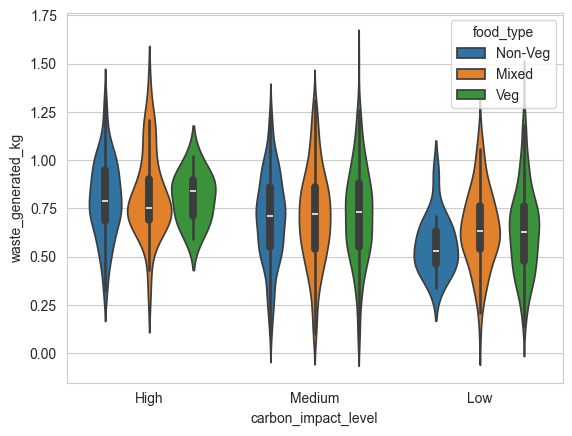

In [89]:
sns.violinplot(x='carbon_impact_level', y='waste_generated_kg', data=co2_df, hue='food_type')

<Axes: xlabel='carbon_impact_level', ylabel='distance_km'>

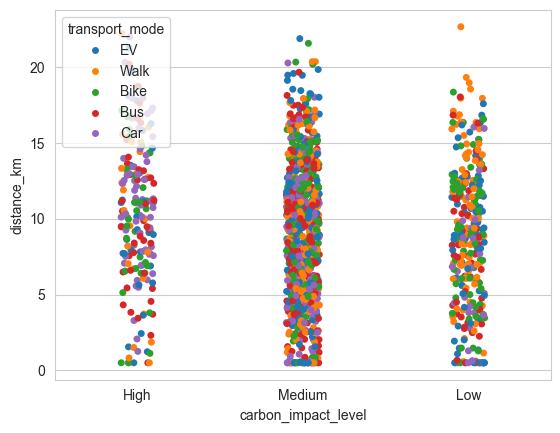

In [92]:
sns.stripplot(x='carbon_impact_level', y='distance_km', data=co2_df, hue='transport_mode')

<Axes: xlabel='carbon_impact_level', ylabel='eco_actions'>

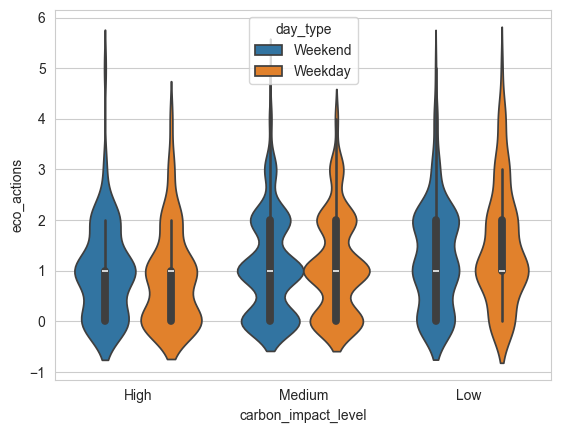

In [94]:
sns.violinplot(x='carbon_impact_level', y='eco_actions', data=co2_df, hue='day_type')

next step is to look at the outlier records and consider whether any should be removed
then to encode transport_mode and food_type
also ensure features exclude screen time and user id

In [96]:
weekend = co2_df['day_type'] == 'Weekend'
elec_kwh_outlier = co2_df['electricity_kwh'] > 11.5
co2_df[weekend & elec_kwh_outlier]

,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
205,30,Weekend,EV,5.96,11.99,50,Mixed,3.2,0.82,1,9.24,Medium
802,115,Weekend,Bike,6.55,12.27,0,Mixed,5.1,0.87,1,14.21,High
993,142,Weekend,Bike,11.09,11.70,50,Veg,3.8,0.57,1,7.09,Medium


In [100]:
co2_df.loc[co2_df['waste_generated_kg']>1.35]

,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
433,62,Weekend,Bus,5.40,7.64,0,Mixed,6.4,1.39,0,11.86,High
522,75,Weekday,EV,12.69,8.40,100,Veg,3.1,1.36,1,3.74,Low
618,89,Weekday,Car,14.27,5.66,50,Veg,6.2,1.51,1,8.73,Medium


In [ ]:
# if I have only 6 outliers is it better to drop of keep. they are not very far outside.

In [26]:
# encode transport hub using target encoding, for both regression (continuous target) and classification (multi target)

# X = co2_df[['day_type', 'transport_mode', 'distance_km', 'electricity_kwh', 'renewable_usage_pct', 'food_type', 'screen_time_hours', 'waste_generated_kg', 'eco_actions']]
X = co2_df[['transport_mode']]
y_cont = co2_df[['carbon_footprint_kg']]
y_multi = co2_df[['carbon_impact_level']]

from sklearn.preprocessing import TargetEncoder

# let other parameters set to thier defaults
enc_cont=TargetEncoder(target_type='continuous')
enc_multi=TargetEncoder(target_type='multiclass')


X_trans_cont = enc_cont.fit_transform(X,np.ravel(y_cont))
X_trans_multi = enc_multi.fit_transform(X,np.ravel(y_multi))

print(enc_cont.encodings_)
print(enc_multi.encodings_)


[array([7.46507719, 8.17448178, 9.08905228, 7.76465183, 7.4777762 ])]
[array([0.10661677, 0.15212085, 0.23195723, 0.11404686, 0.09321408]), array([0.30216178, 0.19217827, 0.12202748, 0.2682735 , 0.31006479]), array([0.59116953, 0.65567565, 0.64566699, 0.61765833, 0.5966366 ])]


In [78]:
X_test_dataset = pd.read_csv('co2_test.csv')
X_test_dataset.info()
X_test_classn = X_test_dataset[['distance_km', 'electricity_kwh', 'renewable_usage_pct', 'screen_time_hours', 'waste_generated_kg', 'eco_actions']]
y_test_knn = X_test_dataset[['carbon_impact_level']]
y_test_logreg = X_test_dataset[['carbon_impact_level']]
y_test_linreg = X_test_dataset[['carbon_footprint_kg']]

test0 = X_test_classn.iloc[0]
test1 = X_test_classn.iloc[1]
test2 = X_test_classn.iloc[2]
test3 = X_test_classn.iloc[3]
test4 = X_test_classn.iloc[4]
test5 = X_test_classn.iloc[5]
test6 = X_test_classn.iloc[6]
test7 = X_test_classn.iloc[7]
test8 = X_test_classn.iloc[8]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              9 non-null      int64  
 1   day_type             9 non-null      object 
 2   transport_mode       9 non-null      object 
 3   distance_km          9 non-null      float64
 4   electricity_kwh      9 non-null      float64
 5   renewable_usage_pct  9 non-null      int64  
 6   food_type            9 non-null      object 
 7   screen_time_hours    9 non-null      float64
 8   waste_generated_kg   9 non-null      float64
 9   eco_actions          9 non-null      int64  
 10  carbon_footprint_kg  9 non-null      float64
 11  carbon_impact_level  9 non-null      object 
dtypes: float64(5), int64(3), object(4)
memory usage: 996.0+ bytes


In [79]:
X = co2_df[['distance_km', 'electricity_kwh', 'renewable_usage_pct', 'screen_time_hours', 'waste_generated_kg', 'eco_actions']]
y_knn = co2_df[['carbon_impact_level']]

from sklearn.neighbors import KNeighborsClassifier
knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_5.fit(X,y_knn)


/Users/elisabethwatson/Birkbeck/PGC ADS/Module 2 Analytic Tools for Data Science/W5 Class material-20251222-2/.venv/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [80]:
X = co2_df[['distance_km', 'electricity_kwh', 'renewable_usage_pct', 'screen_time_hours', 'waste_generated_kg', 'eco_actions']]
y_knn = co2_df[['carbon_impact_level']]

from sklearn.neighbors import KNeighborsClassifier
knn_10 = KNeighborsClassifier(n_neighbors=10)
knn_10.fit(X,y_knn)

/Users/elisabethwatson/Birkbeck/PGC ADS/Module 2 Analytic Tools for Data Science/W5 Class material-20251222-2/.venv/lib/python3.13/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [81]:
X = co2_df[['distance_km', 'electricity_kwh', 'renewable_usage_pct', 'screen_time_hours', 'waste_generated_kg', 'eco_actions']]
y_logreg = co2_df[['carbon_impact_level']]

from sklearn.linear_model import LogisticRegression
logreg_2750 = LogisticRegression(max_iter=2750)
logreg_2750.fit(X, y_logreg)

/Users/elisabethwatson/Birkbeck/PGC ADS/Module 2 Analytic Tools for Data Science/W5 Class material-20251222-2/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [106]:
y_knn5_pred = knn_5.predict(X_test_classn)
y_knn5_pred_all_data = knn_5.predict(X)

In [107]:
y_knn10_pred = knn_10.predict(X_test_classn)
y_knn10_pred_all_data = knn_10.predict(X)

In [108]:
y_logreg_2750_pred = logreg_2750.predict(X_test_classn)
y_logreg_2750_pred_all_data = logreg_2750.predict(X)

In [86]:
X = co2_df[['distance_km', 'electricity_kwh', 'renewable_usage_pct', 'screen_time_hours', 'waste_generated_kg', 'eco_actions']]
y_linreg = co2_df[['carbon_footprint_kg']]

from sklearn.linear_model import LinearRegression
linreg = LinearRegression()
linreg.fit(X, y_linreg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [87]:
y_linreg_pred = linreg.predict(X_test_classn)

In [88]:
co2_df.loc[54]

user_id                      8
day_type               Weekend
transport_mode            Walk
distance_km               4.27
electricity_kwh           7.82
renewable_usage_pct         75
food_type                Mixed
screen_time_hours          6.9
waste_generated_kg         1.1
eco_actions                  3
carbon_footprint_kg       5.22
carbon_impact_level        Low
Name: 54, dtype: object

In [89]:
linreg.predict([[4.27, 7.82, 75, 6.9, 1.1, 3]])

/Users/elisabethwatson/Birkbeck/PGC ADS/Module 2 Analytic Tools for Data Science/W5 Class material-20251222-2/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[6.49713432]])

In [90]:
co2_df.loc[154]

user_id                     23
day_type               Weekday
transport_mode              EV
distance_km              21.89
electricity_kwh           4.72
renewable_usage_pct          0
food_type                Mixed
screen_time_hours          6.9
waste_generated_kg        0.73
eco_actions                  0
carbon_footprint_kg       9.12
carbon_impact_level     Medium
Name: 154, dtype: object

In [91]:
linreg.predict([[21.89, 4.72, 0, 6.9, 0.73, 0]])

/Users/elisabethwatson/Birkbeck/PGC ADS/Module 2 Analytic Tools for Data Science/W5 Class material-20251222-2/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[10.03332637]])

In [92]:
co2_df.loc[3]

user_id                      1
day_type               Weekend
transport_mode            Walk
distance_km                0.5
electricity_kwh          10.16
renewable_usage_pct          0
food_type                Mixed
screen_time_hours          6.3
waste_generated_kg        0.73
eco_actions                  0
carbon_footprint_kg       12.7
carbon_impact_level       High
Name: 3, dtype: object

In [55]:
linreg.predict([[0.5, 10.16, 0, 6.3, 0.73, 0]])

/Users/elisabethwatson/Birkbeck/PGC ADS/Module 2 Analytic Tools for Data Science/W5 Class material-20251222-2/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[11.89892896]])

In [93]:
X = co2_df[['distance_km', 'electricity_kwh', 'renewable_usage_pct', 'screen_time_hours', 'waste_generated_kg', 'eco_actions']]
y_linreg = co2_df[['carbon_footprint_kg']]

from sklearn.preprocessing import PolynomialFeatures
poly_5 = PolynomialFeatures(degree=5)
X_poly5 = poly_5.fit_transform(X)
X_test_classn_poly5 = poly_5.fit_transform(X_test_classn)

linreg_p5 = LinearRegression()
linreg_p5.fit(X_poly5, y_linreg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [94]:
linreg_p5.predict(X_poly5)

array([[10.82982639],
       [ 8.01829565],
       [ 5.97832297],
       ...,
       [ 6.64350833],
       [ 5.7446104 ],
       [ 7.47270393]], shape=(1400, 1))

In [95]:
y_linreg_poly5_pred = linreg_p5.predict(X_test_classn_poly5)

In [96]:
X = co2_df[['distance_km', 'electricity_kwh', 'renewable_usage_pct', 'screen_time_hours', 'waste_generated_kg', 'eco_actions']]
y_linreg = co2_df[['carbon_footprint_kg']]

from sklearn.preprocessing import PolynomialFeatures
poly_10 = PolynomialFeatures(degree=10)
X_poly10 = poly_10.fit_transform(X)
X_test_classn_poly10 = poly_10.fit_transform(X_test_classn)

linreg_p10 = LinearRegression()
linreg_p10.fit(X_poly10, y_linreg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [97]:
linreg_p10.predict(X_poly10)

array([[8.82706009],
       [8.89101452],
       [7.79292887],
       ...,
       [7.26574093],
       [6.68431438],
       [7.22143501]], shape=(1400, 1))

In [98]:
y_linreg_poly10_pred = linreg_p10.predict(X_test_classn_poly10)

In [ ]:
import pandas as pd

df_poly = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(['Years']))
print(df_poly.head())

# assemble all the predictions so far, all tested on the same test dataset

# knn_5: X_test_classn ... y_knn5_pred
# knn_10: X_test_classn ... y_knn5_pred10
# logreg_2750: X_test_classn ... y_logreg_2750_pred
# linreg: X_test_classn ... y_linreg_pred

# linreg_poly5: X-test_classn_poly5 ... y_linreg_poly5_pred
# linreg_poly10: X-test_classn_poly10 .. y_linreg_poly10_pred

Accuracy is a classification metric - for continuous need MSE etc
# linreg_score = metrics.accuracy_score(y_test_linreg,y_linreg_pred)
# linreg_poly5_score = metrics.accuracy_score(y_test_linreg,y_linreg_poly5_pred)
# linreg_poly10_score = metrics.accuracy_score(y_test_linreg,y_linreg_poly10_pred)


In [109]:

from sklearn import metrics

knn_5_score = metrics.accuracy_score(y_test_knn,y_knn5_pred)
knn_10_score = metrics.accuracy_score(y_test_knn,y_knn10_pred)
logreg_2750_score = metrics.accuracy_score(y_test_logreg,y_logreg_2750_pred)
knn_5_score_all_data = metrics.accuracy_score(y_knn,y_knn5_pred_all_data)
knn_10_score_all_data = metrics.accuracy_score(y_knn,y_knn10_pred_all_data)
logreg_2750_score_all_data = metrics.accuracy_score(y_logreg,y_logreg_2750_pred_all_data)

print(knn_5_score)
print(knn_10_score)
print(logreg_2750_score)
print(knn_5_score_all_data)
print(knn_10_score_all_data)
print(logreg_2750_score_all_data)



0.6666666666666666
0.6666666666666666
0.6666666666666666
0.7571428571428571
0.7342857142857143
0.7235714285714285
